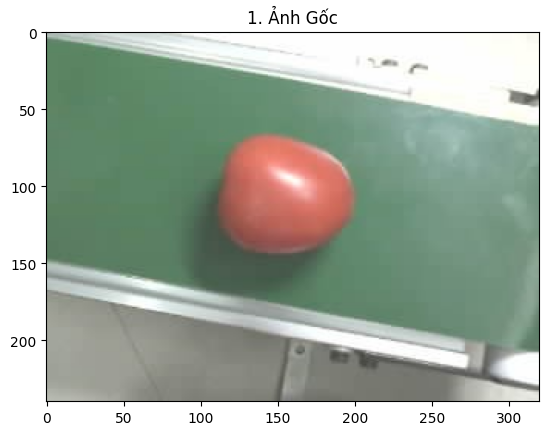

In [50]:
import matplotlib.pyplot as plt
path = '20260411112159.jpg'
image = cv2.imread(path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("1. Ảnh Gốc")
plt.show()

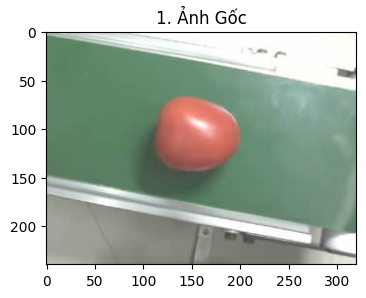

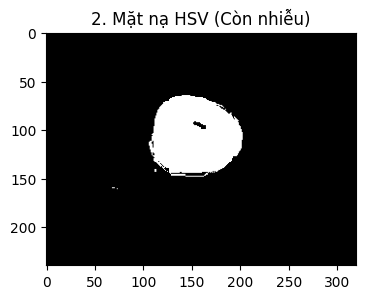

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh (thay bằng đường dẫn ảnh thực tế của bạn)
image = cv2.imread(path) # Cập nhật đường dẫn
img_size = 299

# 1. SHOW ẢNH GỐC
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("1. Ảnh Gốc")
plt.show()

# Tiền xử lý
H, W = image.shape[:2]
center_img_x, center_img_y = W // 2, H // 2
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_red = np.array([0, 35, 50]) 
upper_red = np.array([30, 255, 255])
lower_red_wrap = np.array([160, 35, 50])
upper_red_wrap = np.array([180, 255, 255])
lower_green = np.array([30, 35, 50])
upper_green = np.array([60, 255, 255]) 

mask = cv2.inRange(hsv, lower_red, upper_red)
mask |= cv2.inRange(hsv, lower_red_wrap, upper_red_wrap)
mask |= cv2.inRange(hsv, lower_green, upper_green)

# 2. SHOW MẶT NẠ HSV
plt.figure(figsize=(4,4))
plt.imshow(mask, cmap='gray')
plt.title("2. Mặt nạ HSV (Còn nhiễu)")
plt.show()

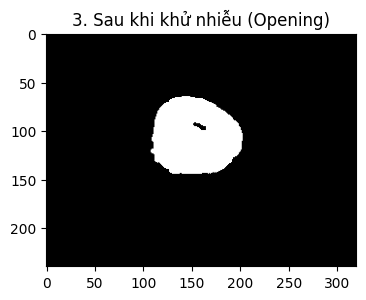

In [53]:
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)) 
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

# 3. SHOW ẢNH ĐÃ KHỬ NHIỄU
plt.figure(figsize=(4,4))
plt.imshow(mask, cmap='gray')
plt.title("3. Sau khi khử nhiễu (Opening)")
plt.show()

In [54]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

best_cnt = None

if contours: # Chỉ chạy nếu tìm thấy ít nhất 1 đường viền
    min_dist = float('inf')
    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue
            
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
            
        dist = (cx - center_img_x)**2 + (cy - center_img_y)**2
        if dist < min_dist:
            min_dist = dist
            best_cnt = cnt

if best_cnt is None:
    print("CẢNH BÁO: Không tìm thấy vật thể nào! Các bước sau có thể bị lỗi.")
else:
    print("Đã tìm thấy vật thể trung tâm.")

Đã tìm thấy vật thể trung tâm.


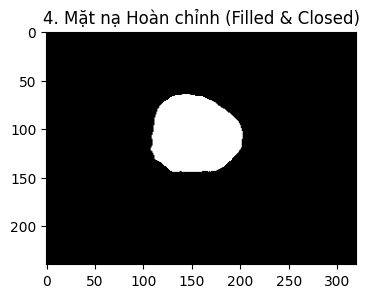

In [55]:
if best_cnt is not None:
    final_mask = np.zeros((H, W), dtype=np.uint8)
    cv2.drawContours(final_mask, [best_cnt], -1, 255, thickness=cv2.FILLED)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_close)

    # 4. SHOW MẶT NẠ HOÀN CHỈNH
    plt.figure(figsize=(4,4))
    plt.imshow(final_mask, cmap='gray')
    plt.title("4. Mặt nạ Hoàn chỉnh (Filled & Closed)")
    plt.show()

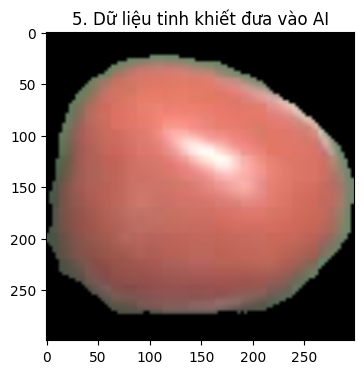

In [56]:
if best_cnt is not None:
    contours_final, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours_final:
        cnt_final = max(contours_final, key=cv2.contourArea)
        
        x, y, w_rect, h_rect = cv2.boundingRect(cnt_final)
        x, y = max(0, x), max(0, y)
        w_rect, h_rect = min(W - x, w_rect), min(H - y, h_rect)
        
        cropped_roi = image[y:y+h_rect, x:x+w_rect]
        cropped_mask = final_mask[y:y+h_rect, x:x+w_rect]
        
        roi_bg_removed = cv2.bitwise_and(cropped_roi, cropped_roi, mask=cropped_mask)
        
        h_crop, w_crop = roi_bg_removed.shape[:2]
        max_side = max(h_crop, w_crop)
        
        top = (max_side - h_crop) // 2
        bottom = max_side - h_crop - top
        left = (max_side - w_crop) // 2
        right = max_side - w_crop - left
        
        squared_img = cv2.copyMakeBorder(
            roi_bg_removed, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, value=[0, 0, 0]
        )
        
        final_output = cv2.resize(squared_img, (img_size, img_size))
        
        # 5. SHOW ẢNH CUỐI CÙNG
        plt.figure(figsize=(4,4))
        plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
        plt.title("5. Dữ liệu tinh khiết đưa vào AI")
        plt.show()

In [ ]:
# Khối 4b: Đổ đặc contour mục tiêu và làm mượt viền
    final_mask = np.zeros((H, W), dtype=np.uint8)

    # Đổ đặc (Fill) lỗ hổng bên trong cà chua
    cv2.drawContours(final_mask, [best_cnt], -1, 255, thickness=cv2.FILLED)

    # Phép toán Đóng (Closing) để làm mượt viền ngoài
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_close)
    
    # (Có thể thêm code show 'final_mask' ở đây để vẽ sơ đồ)

In [ ]:
# Khối 5: Trích xuất vật thể và chuẩn hóa kích thước đầu vào cho AI
    contours_final, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours_final:
        return cv2.resize(image, (img_size, img_size))

    cnt_final = max(contours_final, key=cv2.contourArea)
    
    # 5.1 Tạo Bounding Box và cắt ảnh
    x, y, w_rect, h_rect = cv2.boundingRect(cnt_final)
    x, y = max(0, x), max(0, y)
    w_rect, h_rect = min(W - x, w_rect), min(H - y, h_rect)
    
    cropped_roi = image[y:y+h_rect, x:x+w_rect]
    cropped_mask = final_mask[y:y+h_rect, x:x+w_rect]
    
    # 5.2 Xóa phông (Bitwise AND)
    roi_bg_removed = cv2.bitwise_and(cropped_roi, cropped_roi, mask=cropped_mask)
    
    # 5.3 Thêm viền đen (Padding) để tạo ảnh vuông
    h_crop, w_crop = roi_bg_removed.shape[:2]
    max_side = max(h_crop, w_crop)
    
    top = (max_side - h_crop) // 2
    bottom = max_side - h_crop - top
    left = (max_side - w_crop) // 2
    right = max_side - w_crop - left
    
    squared_img = cv2.copyMakeBorder(
        roi_bg_removed, top, bottom, left, right, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    
    # 5.4 Trả về ảnh đã được Resize đúng chuẩn (299x299)
    return cv2.resize(squared_img, (img_size, img_size))

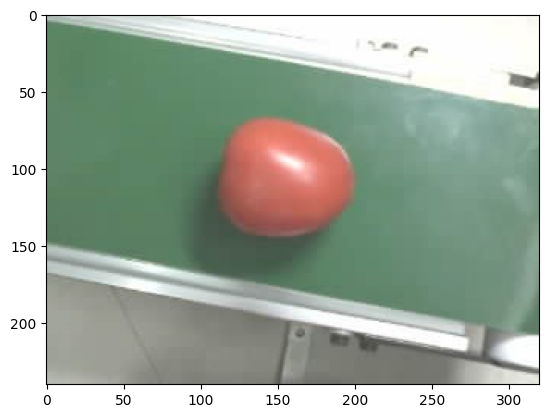

In [ ]:


img = cv2.imread(path)
img_raw = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_raw)


In [35]:
hsv = img

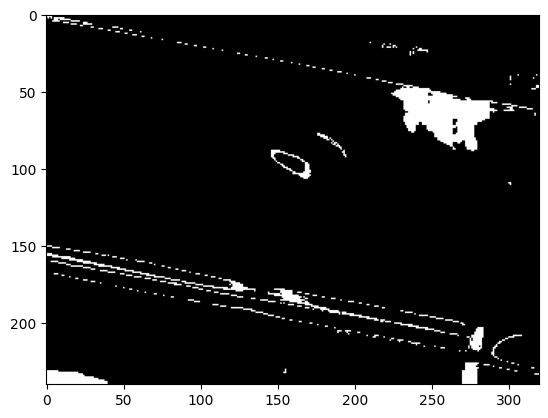

In [36]:
lower_red = np.array([0, 35, 50]) 
upper_red = np.array([30, 255, 255])
lower_red_wrap = np.array([160, 35, 50])
upper_red_wrap = np.array([180, 255, 255])
lower_green = np.array([30, 35, 50])
upper_green = np.array([60, 255, 255]) 
    
mask = cv2.inRange(hsv, lower_red, upper_red)
mask |= cv2.inRange(hsv, lower_red_wrap, upper_red_wrap)
mask |= cv2.inRange(hsv, lower_green, upper_green)

plt.imshow(mask, cmap='gray')

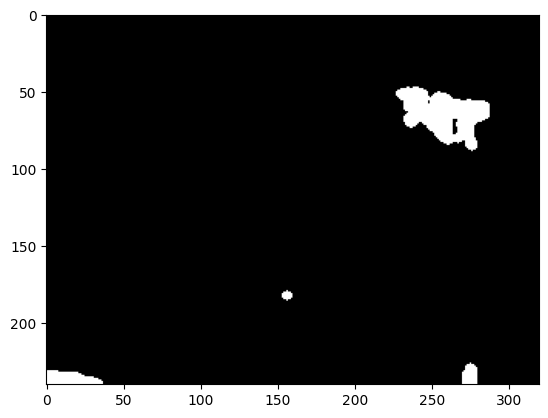

In [37]:
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)) 
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
plt.imshow(mask, cmap='gray')

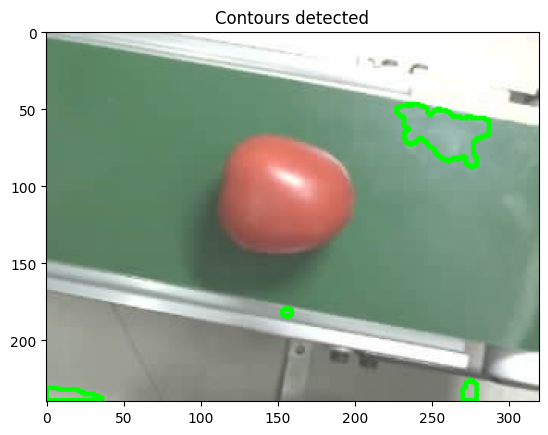

In [38]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    img = cv2.resize(image, (img_size, img_size))
img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0,255,0), 2)
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title("Contours detected")
plt.show()

In [39]:
H, W = img.shape[:2]
center_img_x, center_img_y = W // 2, H // 2

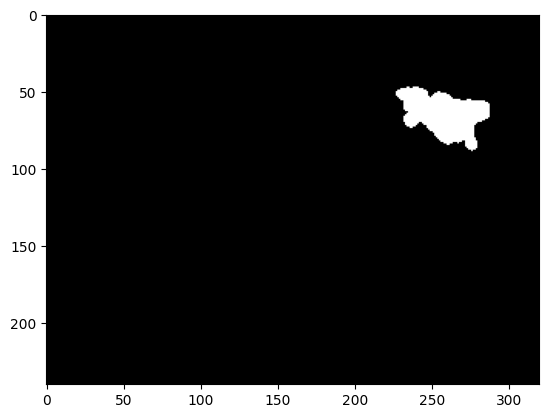

In [40]:
best_cnt = None
min_dist = float('inf')
    
for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue
            
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
            
        dist = (cx - center_img_x)**2 + (cy - center_img_y)**2
        if dist < min_dist:
            min_dist = dist
            best_cnt = cnt
            
if best_cnt is None:
    img = cv2.resize(image, (img_size, img_size))

final_mask = np.zeros((H, W), dtype=np.uint8)
cv2.drawContours(final_mask, [best_cnt], -1, 255, thickness=cv2.FILLED)
plt.imshow(final_mask, cmap='gray')

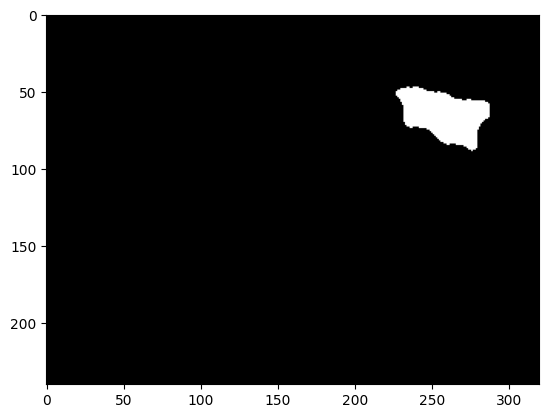

In [41]:
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_close)
plt.imshow(final_mask, cmap='gray')

In [42]:
img_size = 299

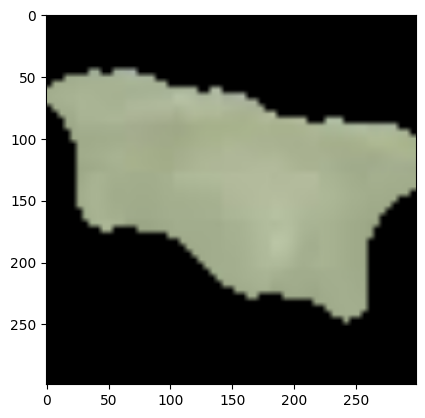

In [43]:
    contours_final, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours_final:
        img = cv2.resize(image, (img_size, img_size))

    cnt_final = max(contours_final, key=cv2.contourArea)
    
    x, y, w_rect, h_rect = cv2.boundingRect(cnt_final)
    x, y = max(0, x), max(0, y)
    w_rect, h_rect = min(W - x, w_rect), min(H - y, h_rect)
    
    cropped_roi = img[y:y+h_rect, x:x+w_rect]
    cropped_mask = final_mask[y:y+h_rect, x:x+w_rect]
    
    roi_bg_removed = cv2.bitwise_and(cropped_roi, cropped_roi, mask=cropped_mask)
    
    h_crop, w_crop = roi_bg_removed.shape[:2]
    max_side = max(h_crop, w_crop)
    
    top = (max_side - h_crop) // 2
    bottom = max_side - h_crop - top
    left = (max_side - w_crop) // 2
    right = max_side - w_crop - left
    
    squared_img = cv2.copyMakeBorder(
        roi_bg_removed, top, bottom, left, right, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    
    img = cv2.resize(squared_img, (img_size, img_size))
    plt.imshow(img)

In [44]:
image = img

In [45]:
    x, y, w, h = cv2.boundingRect(best_cnt)
    x, y = max(0, x), max(0, y)
    w, h = min(W - x, w), min(H - y, h)
    
    cropped_roi = image[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]
    
    roi_bg_removed = cv2.bitwise_and(cropped_roi, cropped_roi, mask=cropped_mask)
    
    h_crop, w_crop = roi_bg_removed.shape[:2]
    max_side = max(h_crop, w_crop)
    
    top = (max_side - h_crop) // 2
    bottom = max_side - h_crop - top
    left = (max_side - w_crop) // 2
    right = max_side - w_crop - left
    
    squared_img = cv2.copyMakeBorder(
        roi_bg_removed, top, bottom, left, right, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    
    img_clean = cv2.resize(squared_img, (img_size, img_size))

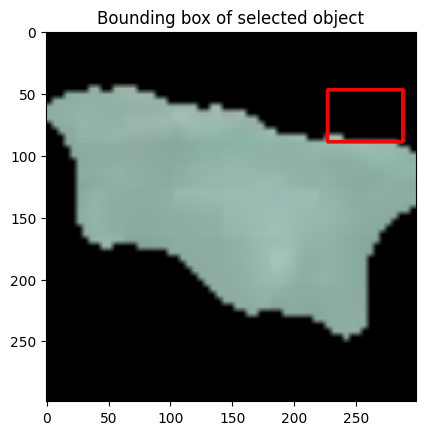

In [46]:
img_bbox = img.copy()
x, y, w, h = cv2.boundingRect(best_cnt)
cv2.rectangle(img_bbox, (x,y), (x+w, y+h), (0,0,255), 2)
plt.imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
plt.title("Bounding box of selected object")
plt.show()


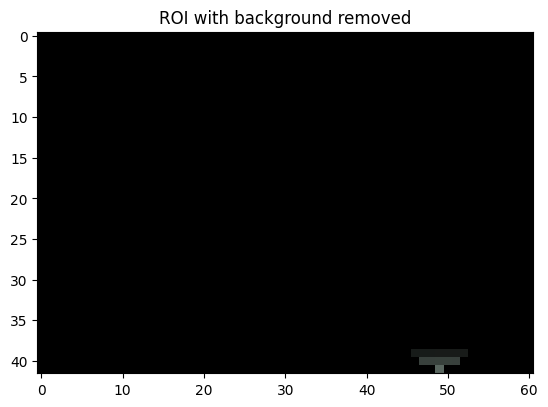

In [47]:
plt.imshow(cv2.cvtColor(roi_bg_removed, cv2.COLOR_BGR2RGB))
plt.title("ROI with background removed")
plt.show()


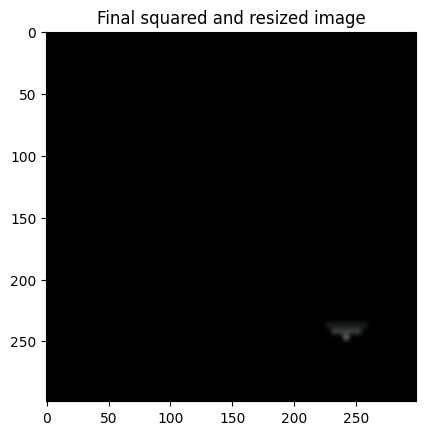

In [48]:
final_img = cv2.resize(squared_img, (img_size, img_size))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Final squared and resized image")
plt.show()
